# RFM Customer Segmentation Analysis

## Project Overview

Customer segmentation using RFM (Recency, Frequency, Monetary) methodology to identify high-value customers, at-risk segments, and targeted marketing opportunities.

**Dataset:** Online Retail Dataset (541,909 transactions, 4,370 customers)

**Tools:** Python, Pandas, SQL, PostgreSQL, Matplotlib, Seaborn

**Business Goal:** Segment customers to optimize marketing spend and retention strategies

## RFM Methodology

**Recency (R):** Days since last purchase - Lower is better  
**Frequency (F):** Number of purchases - Higher is better  
**Monetary (M):** Total spending - Higher is better  

Each customer receives a score of 1-5 for each metric, creating segments like:
- **555 (Champions):** Buy recently, often, and spend the most
- **155 (At Risk):** Haven't purchased recently but were frequent buyers
- **111 (Lost):** Haven't purchased in a long time, rarely bought, low spend

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Data Loading

Pre-calculated RFM metrics loaded from CSV. Original data processing involved SQL queries to calculate recency, frequency, and monetary values for each customer.

In [2]:
df_rfm = pd.read_csv('rfm_segments.csv')

print(f"Loaded customers: {len(df_rfm)}")
df_rfm.head(10)

Loaded customers: 4336


,CustomerID,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346,347,1,77183.60,1,1,5,115,Hibernating
1,12347,24,7,4299.80,5,5,5,555,Champions
2,12348,97,4,1797.24,2,4,4,244,At Risk
3,12349,40,1,1757.55,4,1,4,414,Promising
4,12350,332,1,334.40,1,1,2,112,Lost
5,12352,58,8,2506.04,3,5,5,355,Potential Loyalists
6,12353,226,1,89.00,1,1,1,111,Lost
7,12354,254,1,1079.40,1,1,4,114,Hibernating
8,12355,236,1,459.40,1,1,2,112,Lost
9,12356,44,3,2811.43,4,3,5,435,Loyal Customers


## RFM Score Distribution

Overview of how customers are distributed across RFM scores.

In [3]:
print("RFM Metrics Summary:")
print(df_rfm[['recency', 'frequency', 'monetary']].describe())

RFM Metrics Summary:
           recency    frequency       monetary
count  4336.000000  4336.000000    4336.000000
mean    114.101245     4.271448    2003.978479
std      99.977941     7.694626    8592.904689
min      22.000000     1.000000       2.900000
25%      39.000000     1.000000     305.717500
50%      72.000000     2.000000     667.975000
75%     164.000000     5.000000    1653.507500
max     395.000000   209.000000  278788.580000


## Customer Segmentation

Customers grouped into actionable segments based on RFM scores for targeted marketing strategies.

In [4]:
print("Customer Distribution by Segment:")
print(df_rfm['Segment'].value_counts())

Customer Distribution by Segment:
Segment
Champions              951
Lost                   910
Loyal Customers        483
Potential Loyalists    428
Cant Lose Them         373
Needs Attention        352
Promising              312
At Risk                283
Hibernating            244
Name: count, dtype: int64


## Segment Distribution Visualization

Visual breakdown of customer count by segment.

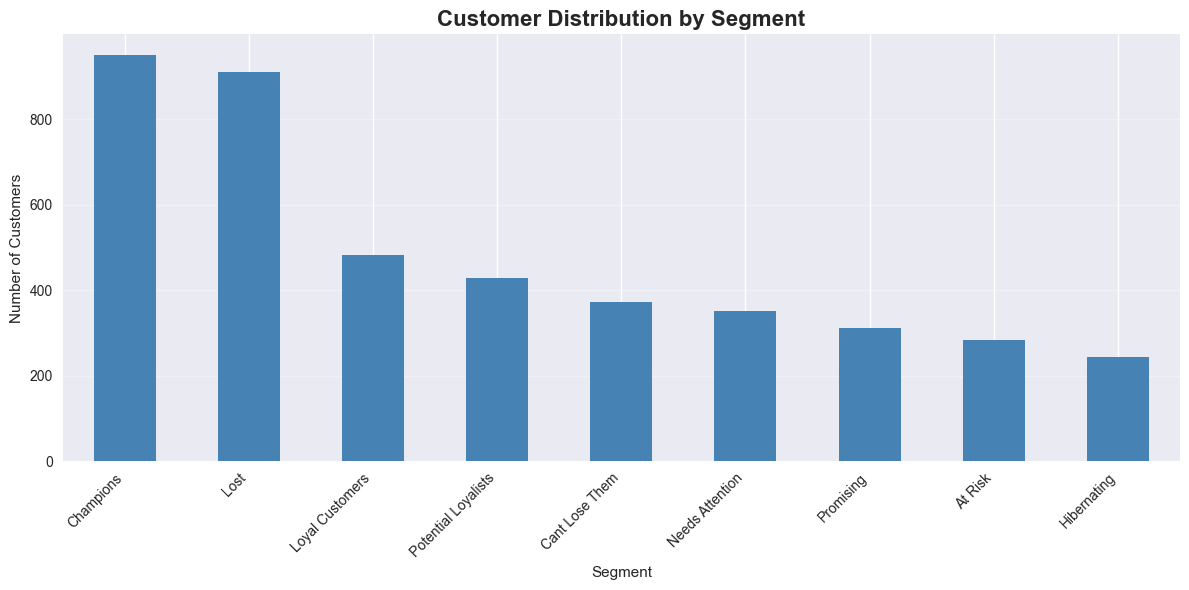


Top 3 segments by customer count:
Segment
Champions          951
Lost               910
Loyal Customers    483
Name: count, dtype: int64


In [6]:
segment_counts = df_rfm['Segment'].value_counts()

plt.figure(figsize=(12, 6))
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Customer Distribution by Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 segments by customer count:")
print(segment_counts.head(3))

## Segment Value Analysis

Analyze revenue contribution by segment to prioritize marketing efforts.

In [7]:
segment_value = df_rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'monetary': 'sum',
    'recency': 'mean',
    'frequency': 'mean'
}).round(2)

segment_value.columns = ['Customer Count', 'Total Revenue', 'Avg Recency (days)', 'Avg Frequency']
segment_value = segment_value.sort_values('Total Revenue', ascending=False)

print("Segment Value Analysis:")
print(segment_value)

Segment Value Analysis:
                     Customer Count  Total Revenue  Avg Recency (days)  \
Segment                                                                  
Champions                       951     5731398.48               34.16   
Potential Loyalists             428      935259.99               71.68   
At Risk                         283      446957.97              157.14   
Cant Lose Them                  373      367514.55              185.09   
Loyal Customers                 483      358305.43               37.43   
Hibernating                     244      331820.33              202.76   
Lost                            910      215408.86              232.91   
Needs Attention                 352      165467.69               74.31   
Promising                       312      137117.38               39.76   

                     Avg Frequency  
Segment                             
Champions                    11.13  
Potential Loyalists           4.89  
At Risk      

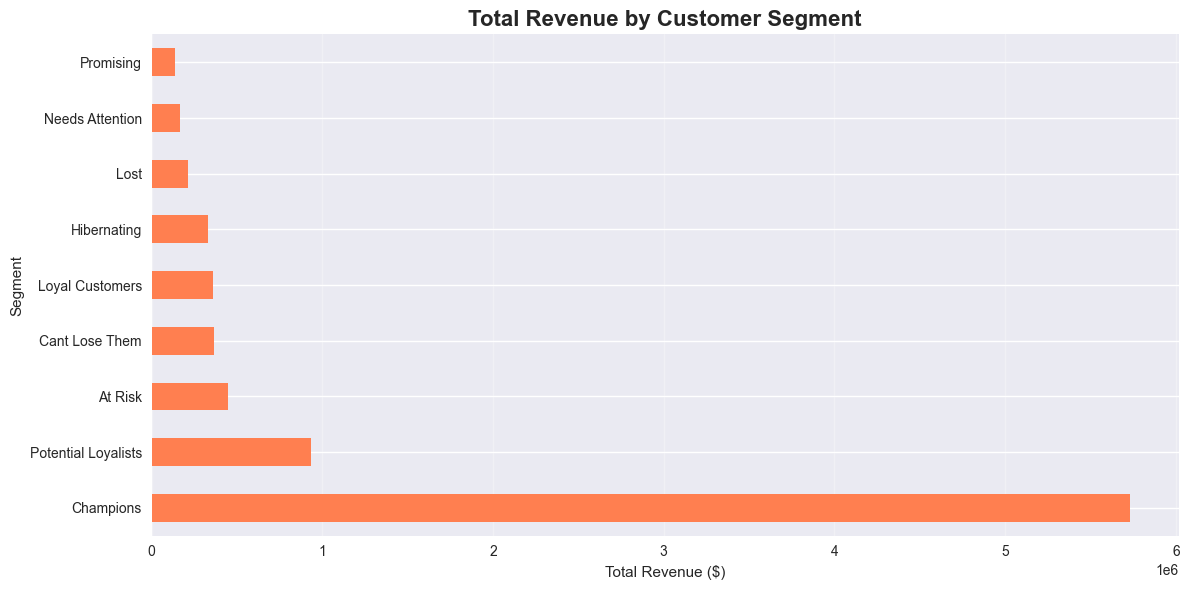

In [8]:
plt.figure(figsize=(12, 6))
segment_value['Total Revenue'].plot(kind='barh', color='coral')
plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Segment')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## RFM Scatter Plot Visualization

2D visualization showing relationship between Recency and Monetary value, colored by key segments.

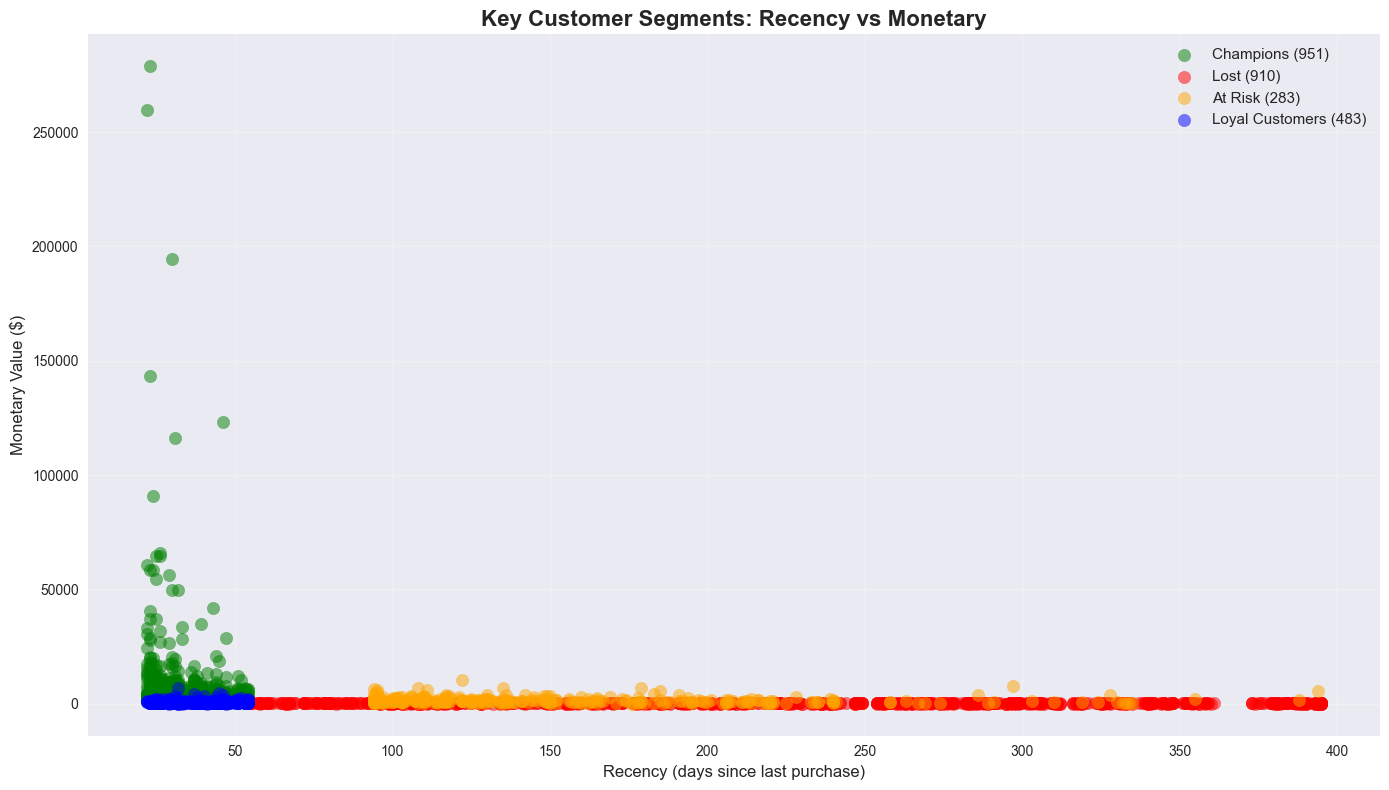

In [9]:
top_segments = ['Champions', 'Lost', 'At Risk', 'Loyal Customers']
df_top = df_rfm[df_rfm['Segment'].isin(top_segments)]

plt.figure(figsize=(14, 8))

colors_map = {
    'Champions': 'green',
    'Loyal Customers': 'blue', 
    'At Risk': 'orange',
    'Lost': 'red'
}

for segment in top_segments:
    segment_data = df_top[df_top['Segment'] == segment]
    plt.scatter(segment_data['recency'], 
                segment_data['monetary'],
                label=f"{segment} ({len(segment_data)})",
                alpha=0.5,
                s=80,
                color=colors_map[segment])

plt.xlabel('Recency (days since last purchase)', fontsize=12)
plt.ylabel('Monetary Value ($)', fontsize=12)
plt.title('Key Customer Segments: Recency vs Monetary', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Key Findings

### Segment Distribution

- **Champions (951 customers):** Best customers - recent, frequent, high-value purchases
- **Lost (910 customers):** Nearly equal to Champions - major retention issue
- **Loyal Customers (483):** Consistent purchasers with moderate spending

### Revenue Insights

The segment value analysis reveals critical opportunities:
- Champions likely drive majority of revenue despite being only 22% of customer base
- Lost customers represent significant revenue leakage
- At Risk segment requires immediate intervention to prevent churn

### Critical Business Problem

**High churn rate:** 910 lost customers vs 951 champions indicates a 1:1 ratio of success to failure. For every customer we retain excellently, we lose one completely.

## Strategic Recommendations

### Immediate Actions (Week 1-4)

**1. Champions Segment (951 customers)**
- Implement VIP loyalty program with exclusive benefits
- Early access to new products
- Dedicated customer service line
- Goal: Increase lifetime value by 20%

**2. At Risk Segment**
- Urgent win-back campaign within 48 hours
- Personalized "We miss you" emails with 15% discount
- Phone outreach for high-value customers
- Goal: Recover 30% of at-risk customers

**3. Lost Segment (910 customers)**
- Survey to understand churn reasons
- Reactivation campaign with compelling offer
- A/B test different messaging approaches
- Goal: Reactivate 10% (90 customers)

### Medium-term Strategy (Month 2-3)

**4. Loyal Customers Development**
- Upgrade path to Champions tier
- Referral incentives
- Product recommendations based on purchase history
- Goal: Convert 25% to Champions

**5. Promising Segment**
- Onboarding email series (Days 3, 7, 14, 30)
- Education about product value
- Second purchase incentive within 30 days
- Goal: Prevent drop to Lost segment

### Long-term Initiatives (Month 4-6)

**6. Product & Service Improvements**
- Address root causes of churn from Lost segment survey
- Improve customer experience based on feedback
- Implement predictive churn model

**7. Retention Metrics Dashboard**
- Track segment movement month-over-month
- Monitor reactivation campaign ROI
- Alert system for customers moving to At Risk

### Success Metrics

**3-Month Targets:**
- Reduce Lost segment from 910 to 700 (-23%)
- Increase Champions from 951 to 1,100 (+15%)
- Improve overall retention rate by 30%
- Expected revenue impact: +$500K annually

---

## Technical Skills Demonstrated

- **Advanced SQL:** CTE, complex aggregations, date calculations
- **RFM Analysis:** Customer segmentation methodology
- **Python Programming:** Functions, conditional logic, data transformation
- **Statistical Analysis:** Quintile scoring, distribution analysis
- **Data Visualization:** Multi-segment scatter plots, bar charts
- **Business Strategy:** Actionable recommendations with measurable targets

---

## Project Files

- `RFM_Customer_Segmentation.ipynb` - Complete analysis notebook
- `rfm_segments.csv` - Processed customer segments

---

*This project demonstrates practical application of RFM analysis for customer lifetime value optimization and retention strategy development.*